## Step 00 — Environment & Config

This cell sets up the global configuration for the entire notebook. Key decisions:

- **2-class task (negative / positive):** The original dataset contains only 209 neutral reviews out of 7,236 (2.9%), with German having just 17. This makes 3-class training impractical — neutral is handled post-hoc via confidence thresholds in the dashboard layer instead.
- **Language-specific models:** Each language gets its own fine-tuned transformer rather than a single multilingual model. Monolingual pre-training provides stronger feature extraction, especially for TR and DE where multilingual baselines underperform.
- **Hyperparameters are language-specific:** EN uses a smaller learning rate (1e-5) with gradient accumulation to simulate larger batches on `roberta-large`. TR and DE use 2e-5 with more epochs to compensate for smaller dataset sizes.
- **GPT-4.1 pseudo-labels** from the `sentiment_binary` column serve as ground truth — these capture sentiment-rating divergence (e.g., 5★ reviews with negative tone) that simple rating-to-label mapping would miss.

In [1]:
# =============================================================================
# STEP 00 — Environment & Config
# Dream Games · Sentiment Analysis (2-Class)
# =============================================================================
import pandas as pd
from pathlib import Path

def section(title: str, width: int = 90, char: str = "="):
    line = char * width
    print("\n" + line)
    print(title)
    print(line)


# ── CONFIG ───────────────────────────────────────────────────────────────────
section("CONFIG")

SEED = 42

LABEL2ID = {"negative": 0, "positive": 1}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

MODELS = {
    "EN": "FacebookAI/roberta-large",
    "TR": "savasy/bert-turkish-text-classification",
    "DE": "deepset/gbert-base",
}

TRAIN_CFG = {
    "max_len":      256,
    "warmup_ratio": 0.10,
    "scheduler":    "cosine",
    "weight_decay": 0.01,
    "lr":         {"EN": 1e-5,  "TR": 2e-5,  "DE": 2e-5},
    "epochs":     {"EN": 4,     "TR": 5,     "DE": 5},
    "batch_size": {"EN": 8,     "TR": 16,    "DE": 16},
    "grad_accum": {"EN": 2,     "TR": 1,     "DE": 1},
    "split_ratio":{"EN": 0.20,  "TR": 0.25,  "DE": 0.25},
}

LANGS = ["EN", "TR", "DE"]

print(f"  SEED     : {SEED}")
print(f"  Labels   : {LABEL2ID}")
print(f"  Task     : 2-class (negative / positive)")
for lang in LANGS:
    print(f"  {lang}      : {MODELS[lang]}")


# ── PATHS ────────────────────────────────────────────────────────────────────
section("PATHS")

# Colab: CSV yüklendi, modeller Drive'a kaydedilecek
DATA_DIR   = Path(".")
MODELS_DIR = Path("/content/drive/MyDrive/SentimentAnalysis/models_v2")
OUT_DIR    = Path("/content/drive/MyDrive/SentimentAnalysis/outputs_v2")

for d in [MODELS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATHS = {
    "reviews":     DATA_DIR / "reviews_sentiment_scope_2025.csv",
    "results":     OUT_DIR  / "sentiment_results.parquet",
    "eval_report": OUT_DIR  / "evaluation_report.csv",
    "model_EN":    MODELS_DIR / "EN",
    "model_TR":    MODELS_DIR / "TR",
    "model_DE":    MODELS_DIR / "DE",
}

for k, v in PATHS.items():
    print(f"  {k:<15} -> {v}")


print("\n✓ Step 00 complete.")


CONFIG
  SEED     : 42
  Labels   : {'negative': 0, 'positive': 1}
  Task     : 2-class (negative / positive)
  EN      : FacebookAI/roberta-large
  TR      : savasy/bert-turkish-text-classification
  DE      : deepset/gbert-base

PATHS
  reviews         -> reviews_sentiment_scope_2025.csv
  results         -> /content/drive/MyDrive/SentimentAnalysis/outputs_v2/sentiment_results.parquet
  eval_report     -> /content/drive/MyDrive/SentimentAnalysis/outputs_v2/evaluation_report.csv
  model_EN        -> /content/drive/MyDrive/SentimentAnalysis/models_v2/EN
  model_TR        -> /content/drive/MyDrive/SentimentAnalysis/models_v2/TR
  model_DE        -> /content/drive/MyDrive/SentimentAnalysis/models_v2/DE

✓ Step 00 complete.


## Step 01 — Data Loading & EDA

Load the review dataset and explore its structure before training. This step covers rating distributions by game and language, review length patterns across ratings, and emoji usage rates. The dataset contains 7,258 reviews across Royal Match and three competitors (Candy Crush Saga, Gardenscapes, Toon Blast) in EN, TR, and DE — with 22 null-sentiment rows that will be dropped in the label engineering step.

In [2]:
df = pd.read_csv(PATHS["reviews"])
print(f"  Shape : {df.shape}")
print(f"  Cols  : {list(df.columns)}")
print(f"\n  Dtypes:\n{df.dtypes.to_string()}")
print(f"\n  Nulls :\n{df.isnull().sum().to_string()}")

  Shape : (7258, 13)
  Cols  : ['review_id', 'game', 'country', 'lang', 'rating', 'title', 'review', 'date', 'version', 'days_since_version', 'is_competitor', 'sentiment_binary', 'sentiment_3class']

  Dtypes:
review_id              int64
game                  object
country               object
lang                  object
rating                 int64
title                 object
review                object
date                  object
version               object
days_since_version     int64
is_competitor          int64
sentiment_binary      object
sentiment_3class      object

  Nulls :
review_id              0
game                   0
country                0
lang                   0
rating                 0
title                  0
review                 0
date                   0
version                0
days_since_version     0
is_competitor          0
sentiment_binary      22
sentiment_3class      22



1B — Rating Distribution by Game


/tmp/ipykernel_6364/1072819505.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{r}★" for r in range(1, 6)], fontsize=11)


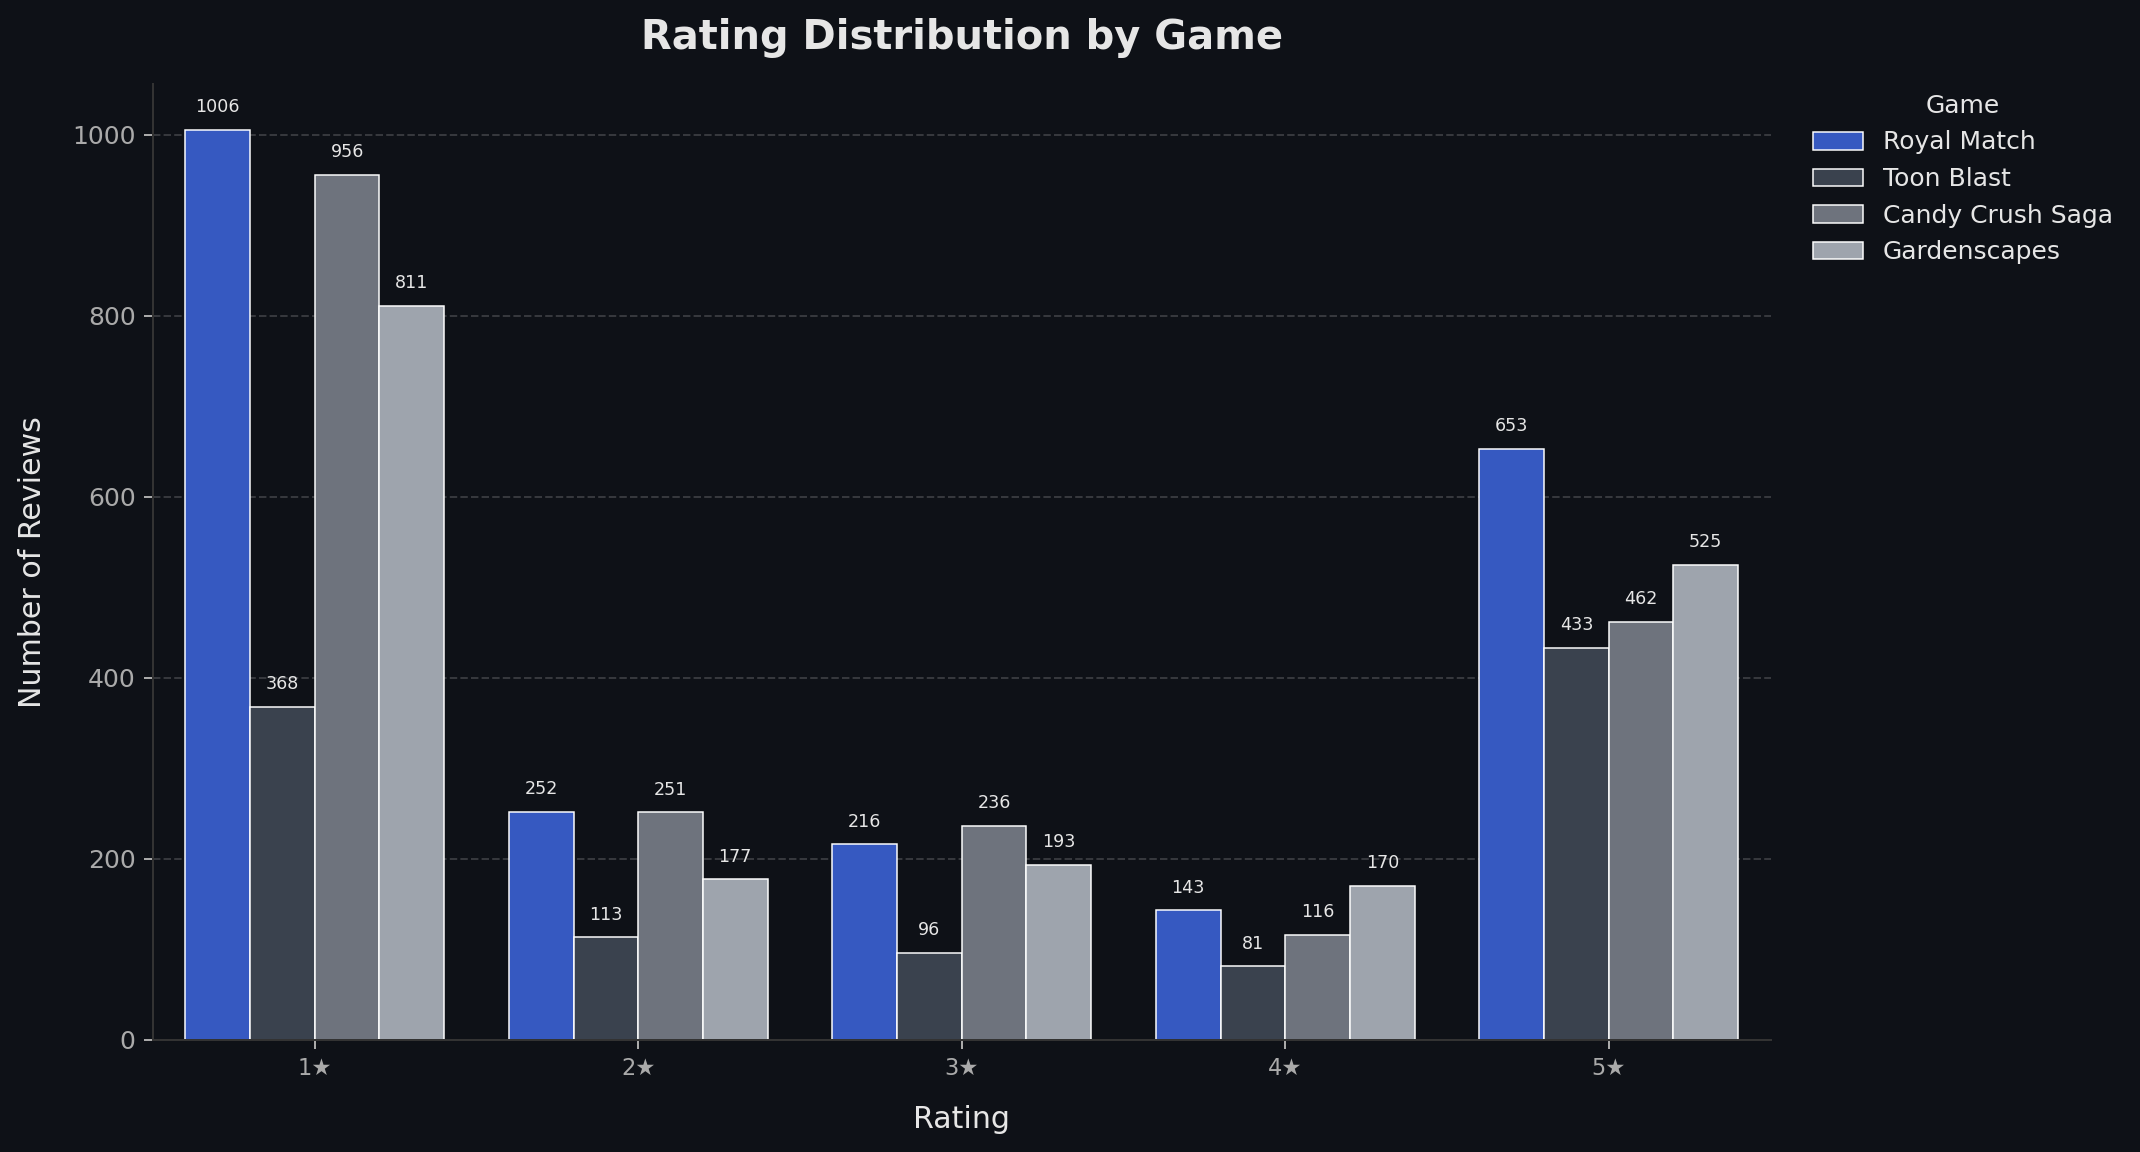

In [3]:
section("1B — Rating Distribution by Game")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#E6E6E6",
    "xtick.color":      "#AAAAAA",
    "ytick.color":      "#AAAAAA",
    "text.color":       "#E6E6E6",
    "axes.grid":        False,
    "axes.axisbelow":   True,
    "figure.dpi":       180,
    "legend.frameon":   False,
})

LANG_PALETTE = {"EN": "#66C2A5", "TR": "#FC8D62", "DE": "#7FA2E8"}
GAME_ORDER      = ["Royal Match", "Toon Blast", "Candy Crush Saga", "Gardenscapes"]
HIGHLIGHT_GAME  = "Royal Match"
HIGHLIGHT_COLOR = "#1f4ed8"
COMPETITOR_PALETTE = {
    "Toon Blast":       "#374151",
    "Candy Crush Saga": "#6b7280",
    "Gardenscapes":     "#9ca3af",
}

def make_game_palette():
    return {HIGHLIGHT_GAME: HIGHLIGHT_COLOR, **COMPETITOR_PALETTE}

rating_by_game = (
    df.groupby(["rating", "game"])
    .size()
    .reset_index(name="n_reviews")
)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=rating_by_game,
    x="rating", y="n_reviews",
    hue="game", hue_order=GAME_ORDER,
    palette=make_game_palette(),
    edgecolor="white", linewidth=0.6,
    ax=ax
)

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + max(2, int(rating_by_game["n_reviews"].max() * 0.015)),
                f"{int(h)}", ha="center", va="bottom", fontsize=7
            )

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_title("Rating Distribution by Game", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Rating", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Reviews", fontsize=12, labelpad=10)
ax.set_xticklabels([f"{r}★" for r in range(1, 6)], fontsize=11)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Game", bbox_to_anchor=(1.02, 1), loc="upper left",
          borderaxespad=0, frameon=False, fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

> **Key observation:** The dataset is heavily skewed toward **1★ ratings** across all four games — this is by design, as the review collection pipeline prioritized negative reviews for product insight. Royal Match leads in both **1★ (1,006)** and **5★ (653)** volume, reflecting its larger user base. The **4★ bracket is the thinnest** across all games, which is typical for mobile — users either love or hate, rarely land in between.


1C — Rating Distribution by Language


/tmp/ipykernel_6364/2161831223.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{r}★" for r in range(1, 6)], fontsize=11)


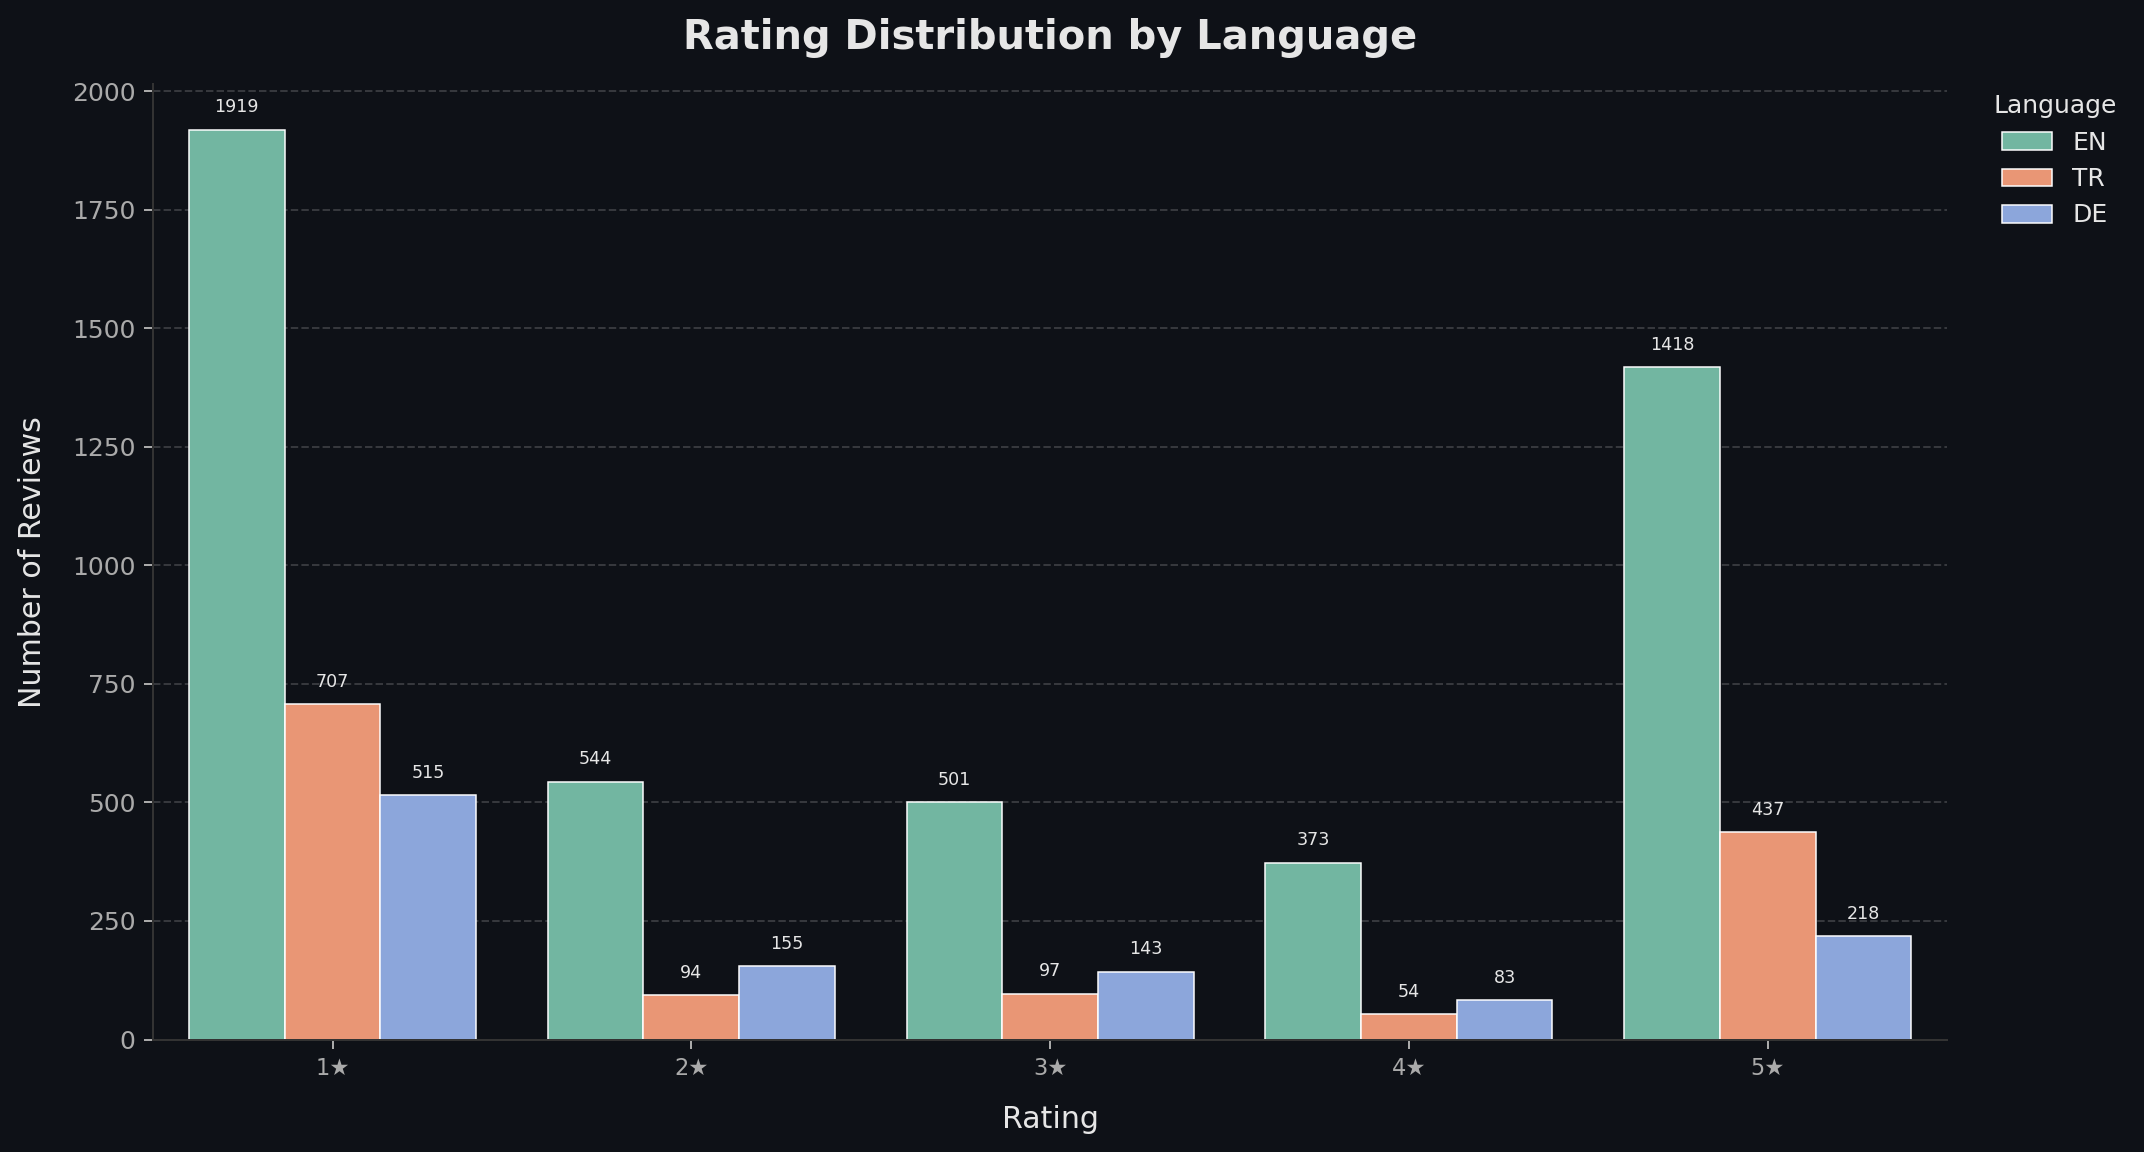

In [4]:
section("1C — Rating Distribution by Language")

rating_by_lang = (
    df.groupby(["rating", "lang"])
    .size()
    .reset_index(name="n_reviews")
)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=rating_by_lang,
    x="rating", y="n_reviews",
    hue="lang", hue_order=LANGS,
    palette=LANG_PALETTE,
    edgecolor="white", linewidth=0.6,
    ax=ax
)

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + max(2, int(rating_by_lang["n_reviews"].max() * 0.015)),
                f"{int(h)}", ha="center", va="bottom", fontsize=7
            )

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_title("Rating Distribution by Language", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Rating", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Reviews", fontsize=12, labelpad=10)
ax.set_xticklabels([f"{r}★" for r in range(1, 6)], fontsize=11)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left",
          borderaxespad=0, frameon=False, fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

> **Key observation:** The U-shaped polarization holds across all languages, but with notable differences in intensity. **EN is the most balanced** — 1★ accounts for ~40% and 5★ for ~30%, leaving a meaningful middle. **TR and DE are more negatively skewed** — in TR, 1★ alone makes up ~51% of all reviews, while 5★ is ~31%. DE shows a similar pattern with 1★ at ~46% and 5★ at ~20%. This heavier negative skew in TR and DE directly impacts class imbalance for training (neg:pos ratios of **4.4:1** and **3.9:1** vs EN's **2.1:1**), which is why weighted loss is essential for these languages.


1D — Review Length by Rating × Language
  Median char count per lang × rating:
rating    1    2    3    4   5
lang                          
DE      180  219  224  157  84
EN      149  200  185  148  58
TR      119  121  106  124  60


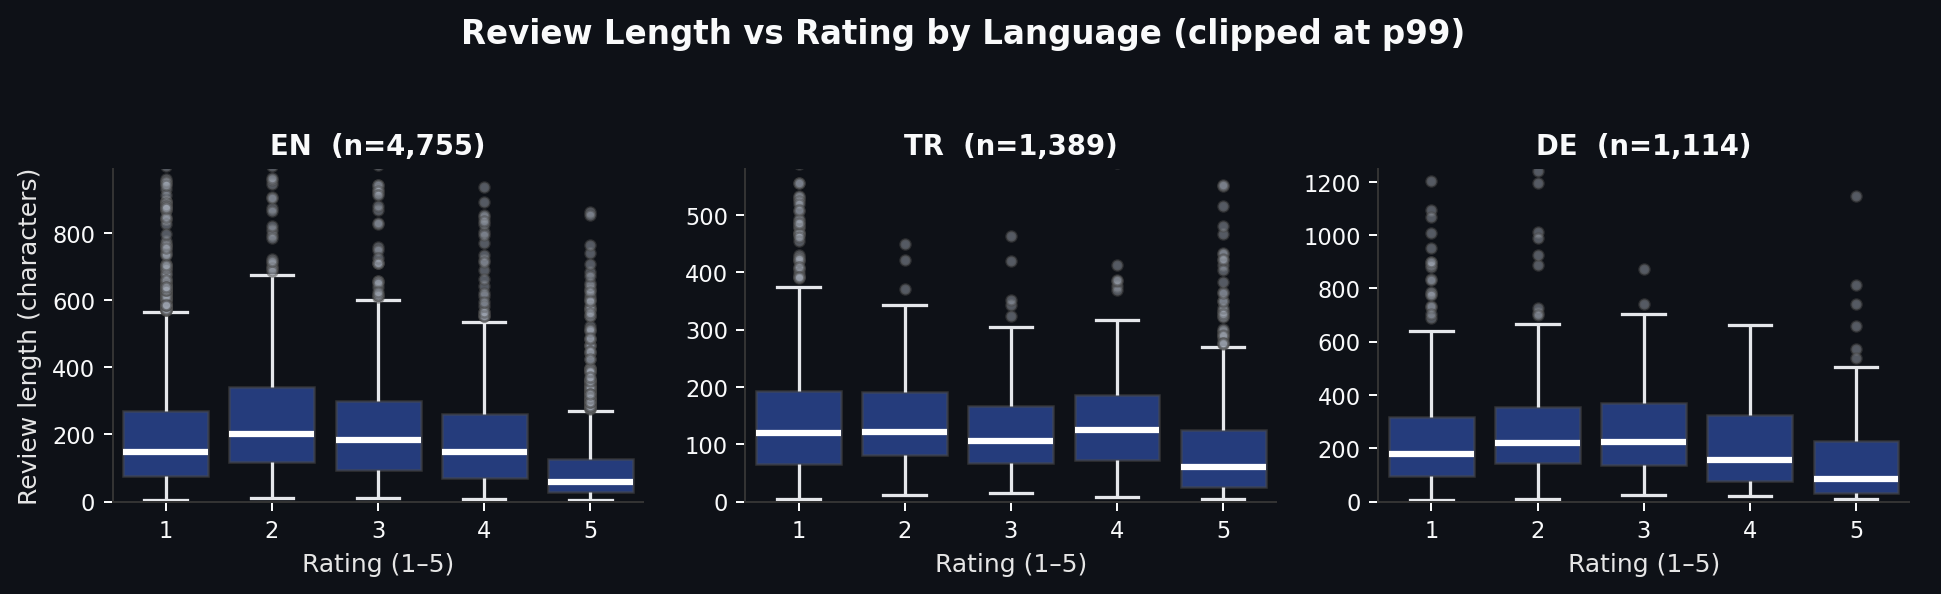

In [5]:
section("1D — Review Length by Rating × Language")

df["char_count"] = df["review"].str.len()

medians = df.groupby(["lang", "rating"])["char_count"].median().round(0).astype(int)
print("  Median char count per lang × rating:")
print(medians.unstack("rating").to_string())

g = sns.catplot(
    data=df,
    x="rating",
    y="char_count",
    col="lang",
    col_order=LANGS,
    col_wrap=3,
    kind="box",
    height=3.1,
    aspect=1.15,
    sharey=False,
    color="#1f4ed8",
    showfliers=True,
    boxprops={"alpha": 0.6},
    medianprops={"color": "white", "linewidth": 2.5},
    whiskerprops={"color": "#E5E7EB", "linewidth": 1.3},
    capprops={"color": "#E5E7EB", "linewidth": 1.3},
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#9CA3AF",
        "alpha": 0.5,
    },
)

for ax in g.axes.flatten():
    lang = ax.get_title().split(" = ")[-1]
    sub = df[df["lang"] == lang]
    upper = sub["char_count"].quantile(0.99)
    ax.set_ylim(0, upper * 1.05)
    n = len(sub)
    ax.set_title(f"{lang}  (n={n:,})", fontsize=11, weight="bold", color="#F9FAFB")
    ax.tick_params(axis="x", labelsize=9, colors="#F9FAFB")
    ax.tick_params(axis="y", labelsize=9, colors="#F9FAFB")

g.set_axis_labels("Rating (1–5)", "Review length (characters)", fontsize=10)
plt.suptitle(
    "Review Length vs Rating by Language (clipped at p99)",
    y=1.05, fontsize=13, weight="bold", color="#F9FAFB",
)
plt.tight_layout()
plt.show()

> **Key observation:** A clear pattern across all three languages — **5★ reviews are significantly shorter** (EN median 58, TR 60, DE 84 chars) while **2★ and 3★ reviews tend to be the longest**. This makes sense: satisfied users leave quick praise, while dissatisfied users elaborate on their complaints. DE reviews are consistently longer than EN and TR across all ratings, likely due to German compound word structure. The `max_len=256` tokenization limit is well-chosen — it comfortably covers the vast majority of reviews without truncation.

In [6]:
import re

EMOJI_RE = re.compile(
    "[\U00010000-\U0010FFFF\U0001F300-\U0001F9FF\u2600-\u26FF\u2700-\u27BF]+",
    flags=re.UNICODE,
)
df["has_emoji"] = df["review"].apply(lambda x: bool(EMOJI_RE.search(str(x))))
emoji_rate = df.groupby("lang")["has_emoji"].mean().mul(100).round(1).reindex(LANGS)
print("  Emoji rate (%) per language:")
print(emoji_rate.to_string())

  Emoji rate (%) per language:
lang
EN    7.2
TR    6.8
DE    9.8


### Step 01 — Takeaways

The dataset contains **7,258 reviews** across 4 games and 3 languages, heavily skewed toward 1★ ratings. The U-shaped rating polarization (1★ and 5★ dominant, 4★ thinnest) is consistent across all languages, confirming that mobile users write reviews when they feel strongly. **Class imbalance varies by language** — EN has a manageable 2.1:1 neg:pos ratio, while TR (4.4:1) and DE (3.9:1) are more severe, making weighted loss critical. Review lengths are short enough that `max_len=256` tokens will cover the vast majority without truncation. These patterns inform two key training decisions: **language-specific models** (different imbalance ratios and linguistic structures) and **balanced class weights** (to prevent the model from defaulting to the majority class).

## Step 02 — Text Cleaning

Minimal preprocessing before tokenization. Transformer models (RoBERTa, BERT) have their own tokenizers that handle punctuation, casing, and special characters natively — aggressive cleaning (lowercasing, stopword removal, etc.) would actually hurt performance by removing signal. We only apply **NFKC unicode normalization** for consistency and **whitespace collapse** to clean up formatting artifacts.

In [7]:
section("2A — Text Cleaning")

import unicodedata

WS_RE = re.compile(r"\s+")

def clean_review(text: str) -> str:
    # NFKC normalization — consistent with topic modeling pipeline
    # RoBERTa / XLM-RoBERTa handle punctuation, casing, and repetition natively
    t = unicodedata.normalize("NFKC", str(text))
    t = WS_RE.sub(" ", t).strip()
    return t

df["review_clean"] = df["review"].apply(clean_review)

n_changed = (df["review"] != df["review_clean"]).sum()
print(f"  Reviews changed after cleaning : {n_changed} / {len(df)}")

changed = df[df["review"] != df["review_clean"]][["review", "review_clean"]].iloc[0]
print(f"\n  Before: {changed['review']}")
print(f"\n  After : {changed['review_clean']}")


2A — Text Cleaning
  Reviews changed after cleaning : 1226 / 7258

  Before: This game is a lie you  never help the king and do the mini games the worst game ever made and I’ve ever played

  After : This game is a lie you never help the king and do the mini games the worst game ever made and I’ve ever played


## Step 03 — Label Engineering

This step defines the training labels. Instead of mapping star ratings to sentiment (which misses cases like 5★ reviews with negative tone), we use **GPT-4.1 pseudo-labels** from the `sentiment_binary` column as ground truth. 22 reviews with null sentiment are dropped. The result is a **2-class label set (negative / positive)** — the neutral class was excluded due to insufficient samples (209 total, just 17 in DE).


3A — Label Engineering (2-Class, GPT Labels)
  Dropped 22 null-sentiment rows

  Label distribution (overall):
label
negative    5179
positive    2057

  Label distribution by language:
    EN (n=4744): negative=3193 (67.3%)  positive=1551 (32.7%)
    TR (n=1380): negative=1108 (80.3%)  positive=272 (19.7%)
    DE (n=1112): negative=878 (79.0%)  positive=234 (21.0%)

3B — Label Distribution by Language


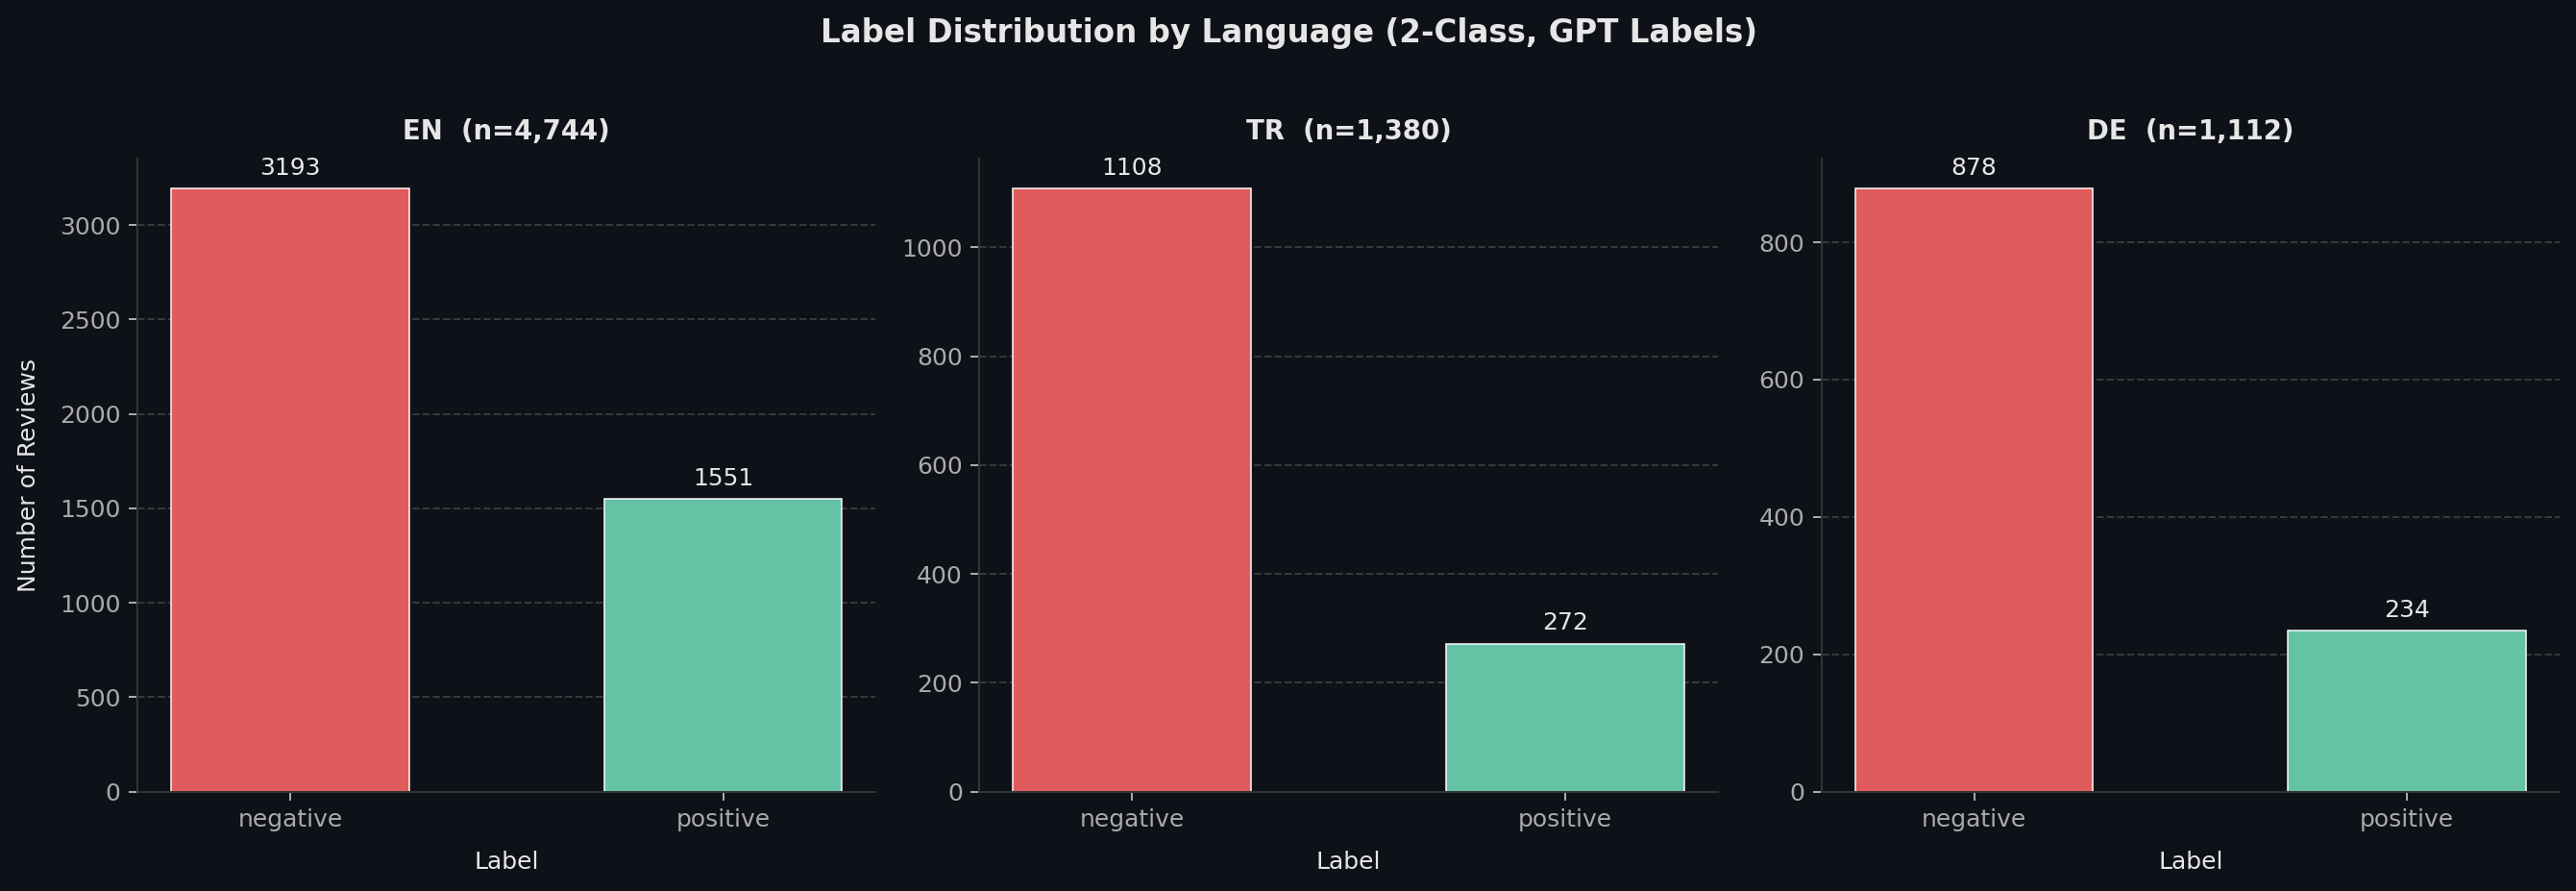

In [8]:
section("3A — Label Engineering (2-Class, GPT Labels)")

# Null sentiment'leri drop et (22 adet, çok kısa review'lar)
n_before = len(df)
df = df.dropna(subset=["sentiment_3class"]).copy()
print(f"  Dropped {n_before - len(df)} null-sentiment rows")

# 2-class label: neutral → sentiment_binary'den al (GPT zaten atamış)
df["label"] = df["sentiment_binary"]
df["label_id"] = df["label"].map(LABEL2ID)

print(f"\n  Label distribution (overall):")
print(df["label"].value_counts().to_string())

print(f"\n  Label distribution by language:")
for lang in LANGS:
    sub = df[df["lang"] == lang]
    vc = sub["label"].value_counts()
    total = len(sub)
    print(f"    {lang} (n={total}): negative={vc.get('negative',0)} ({vc.get('negative',0)/total*100:.1f}%)  positive={vc.get('positive',0)} ({vc.get('positive',0)/total*100:.1f}%)")


section("3B — Label Distribution by Language")

label_order  = ["negative", "positive"]
label_colors = {"negative": "#E05C5C", "positive": "#66C2A5"}

dist = df.groupby(["lang", "label"]).size().reset_index(name="n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, lang in zip(axes, LANGS):
    sub = dist[dist["lang"] == lang].set_index("label").reindex(label_order).fillna(0)
    bars = ax.bar(sub.index, sub["n"],
                  color=[label_colors[l] for l in sub.index],
                  edgecolor="white", linewidth=0.6, width=0.55)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + max(2, int(sub["n"].max() * 0.015)),
                    str(int(h)), ha="center", va="bottom", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_title(f"{lang}  (n={dist[dist['lang']==lang]['n'].sum():,})",
                 fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Label", fontsize=10, labelpad=8)
    if ax is axes[0]:
        ax.set_ylabel("Number of Reviews", fontsize=10, labelpad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Label Distribution by Language (2-Class, GPT Labels)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> **Key observation:** After dropping 22 null rows, we have **7,236 training-ready reviews** with a **71.6% negative / 28.4% positive** overall split. The imbalance intensifies by language — EN is relatively manageable at **67/33**, but **TR (80/20) and DE (79/21)** are heavily skewed. This ~4:1 neg:pos ratio in TR and DE means the model could reach ~80% accuracy by always predicting negative — which is why **balanced class weights in the loss function** are essential to force the model to learn the positive class properly.

## Step 04 — Train / Val / Test Split & Class Weights

Stratified splitting ensures label proportions are preserved across train, validation, and test sets. EN uses an 80/10/10 split, while TR and DE use 75/12.5/12.5 to keep validation and test sets large enough for reliable evaluation on smaller datasets. Balanced class weights are computed from the training set and will be passed to the loss function during fine-tuning.

In [9]:
section("4A — Stratified Split")

from sklearn.model_selection import train_test_split

def split_lang(df_lang, test_val_size):
    train, temp = train_test_split(
        df_lang, test_size=test_val_size,
        stratify=df_lang["label"], random_state=SEED
    )
    val, test = train_test_split(
        temp, test_size=0.5,
        stratify=temp["label"], random_state=SEED
    )
    return train, val, test

splits = {}
for lang in LANGS:
    df_lang = df[df["lang"] == lang].copy()
    train, val, test = split_lang(df_lang, TRAIN_CFG["split_ratio"][lang])
    splits[lang] = {"train": train, "val": val, "test": test}
    print(f"  {lang} → train: {len(train)}  val: {len(val)}  test: {len(test)}")


section("4B — Split Quality Check")

for lang in LANGS:
    print(f"\n  {lang} label distribution (%):")
    for split_name in ["train", "val", "test"]:
        dist = (
            splits[lang][split_name]["label"]
            .value_counts(normalize=True)
            .mul(100).round(1)
            .reindex(["negative", "positive"])
        )
        print(f"    {split_name:<6} : {dist.to_dict()}")


section("4C — Class Weights")

import torch
from sklearn.utils.class_weight import compute_class_weight

class_weights = {}
for lang in LANGS:
    labels  = splits[lang]["train"]["label"].map(LABEL2ID).values
    classes = sorted(set(labels))
    weights = compute_class_weight("balanced", classes=np.array(classes), y=labels)
    class_weights[lang] = torch.tensor(weights, dtype=torch.float)
    print(f"  {lang} : {dict(zip([ID2LABEL[c] for c in classes], weights.round(3)))}")


4A — Stratified Split
  EN → train: 3795  val: 474  test: 475
  TR → train: 1035  val: 172  test: 173
  DE → train: 834  val: 139  test: 139

4B — Split Quality Check

  EN label distribution (%):
    train  : {'negative': 67.3, 'positive': 32.7}
    val    : {'negative': 67.3, 'positive': 32.7}
    test   : {'negative': 67.4, 'positive': 32.6}

  TR label distribution (%):
    train  : {'negative': 80.3, 'positive': 19.7}
    val    : {'negative': 80.2, 'positive': 19.8}
    test   : {'negative': 80.3, 'positive': 19.7}

  DE label distribution (%):
    train  : {'negative': 78.9, 'positive': 21.1}
    val    : {'negative': 79.1, 'positive': 20.9}
    test   : {'negative': 79.1, 'positive': 20.9}

4C — Class Weights
  EN : {'negative': np.float64(0.743), 'positive': np.float64(1.529)}
  TR : {'negative': np.float64(0.623), 'positive': np.float64(2.537)}
  DE : {'negative': np.float64(0.634), 'positive': np.float64(2.369)}


> **Key observation:** Stratification is working correctly — label proportions are **nearly identical** across train/val/test for all three languages (±0.2% variance). Class weights reflect the imbalance: positive class gets **1.5x weight in EN**, but **2.5x in TR** and **2.4x in DE**, forcing the model to treat each positive sample as worth ~2.5 negative samples during training. DE has the smallest test set at **139 samples** — this is why we'll run **5-fold CV** later to validate that test results aren't driven by a lucky split.

## Step 05 — Zero-shot Baseline

Before fine-tuning, we establish a baseline using `lxyuan/distilbert-base-multilingual-cased-sentiments-student` — a lightweight multilingual sentiment model. Since it outputs 3-class predictions, neutral outputs are resolved by falling back to whichever of negative/positive has the higher score. This baseline sets the floor that our fine-tuned models must beat.

In [10]:
section("5A — Zero-shot Baseline Model Load")

from transformers import pipeline

zs_model = pipeline(
    "text-classification",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    top_k=None,
    device=0 if torch.cuda.is_available() else -1,
)
print("  Model loaded.")


section("5B — Zero-shot Inference")

def predict_zeroshot_binary(texts):
    results = zs_model(texts, batch_size=32, truncation=True, max_length=256)
    preds = []
    for r in results:
        top = max(r, key=lambda x: x["score"])
        if top["label"] == "neutral":
            # neutral çıkarsa, neg ve pos arasından yüksek olanı al
            scores = {s["label"]: s["score"] for s in r}
            preds.append("negative" if scores["negative"] >= scores["positive"] else "positive")
        else:
            preds.append(top["label"])
    return preds

zs_preds = {}
for lang in LANGS:
    val_df = splits[lang]["val"]
    texts  = val_df["review_clean"].tolist()
    preds  = predict_zeroshot_binary(texts)
    zs_preds[lang] = {"preds": preds, "labels": val_df["label"].tolist()}
    print(f"  {lang} inference done — {len(preds)} reviews")


section("5C — Zero-shot Evaluation")

from sklearn.metrics import classification_report

for lang in LANGS:
    preds  = zs_preds[lang]["preds"]
    labels = zs_preds[lang]["labels"]
    print(f"\n  {lang}:")
    print(classification_report(labels, preds,
                                 labels=["negative", "positive"],
                                 zero_division=0))


5A — Zero-shot Baseline Model Load


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

  Model loaded.

5B — Zero-shot Inference
  EN inference done — 474 reviews
  TR inference done — 172 reviews
  DE inference done — 139 reviews

5C — Zero-shot Evaluation

  EN:
              precision    recall  f1-score   support

    negative       0.95      0.77      0.85       319
    positive       0.67      0.92      0.77       155

    accuracy                           0.82       474
   macro avg       0.81      0.85      0.81       474
weighted avg       0.86      0.82      0.83       474


  TR:
              precision    recall  f1-score   support

    negative       0.90      0.83      0.86       138
    positive       0.48      0.65      0.55        34

    accuracy                           0.79       172
   macro avg       0.69      0.74      0.71       172
weighted avg       0.82      0.79      0.80       172


  DE:
              precision    recall  f1-score   support

    negative       0.90      0.85      0.87       110
    positive       0.53      0.66      0.58  

> **Key observation:** The zero-shot baseline reveals a clear pattern — **EN performs reasonably (macro F1: 0.81)** but **TR (0.71) and DE (0.73) struggle badly on the positive class** (F1 of 0.55 and 0.58). The multilingual model's positive precision is below 0.50 in TR — meaning **more than half** of its positive predictions are wrong. This confirms that a generic multilingual model is insufficient for non-English languages and validates our approach of **fine-tuning language-specific models**. These scores are our benchmark: any fine-tuned model that doesn't substantially exceed them isn't worth deploying.

## Step 06 — Fine-tuning

This is the core training step. Each language gets its own transformer fine-tuned on GPT-4.1 pseudo-labels: `roberta-large` for EN, `savasy/bert-turkish-text-classification` for TR, and `deepset/gbert-base` for DE. A custom `WeightedTrainer` passes balanced class weights to the cross-entropy loss, forcing the model to pay proportionally more attention to the minority positive class. Training uses cosine learning rate scheduling with 10% warmup, and the best checkpoint is selected based on validation F1 at each epoch.

#### 6A — Tokenization & Dataset Preparation

Each language uses its own tokenizer matching its pre-trained model. Reviews are tokenized with `max_length=256` and `padding="max_length"` — this converts raw text into fixed-length input tensors the model can consume. Each split (train/val/test) is converted into a HuggingFace `Dataset` object with only `input_ids`, `attention_mask`, and `labels` retained.

In [11]:
section("6A — Tokenization & Dataset Preparation")

from transformers import AutoTokenizer
from datasets import Dataset

def tokenize(batch, tokenizer):
    return tokenizer(
        batch["review_clean"],
        truncation=True,
        padding="max_length",
        max_length=TRAIN_CFG["max_len"]
    )

tokenizers = {}
datasets   = {}

for lang in LANGS:
    tokenizer = AutoTokenizer.from_pretrained(MODELS[lang])
    tokenizers[lang] = tokenizer

    ds = {}
    for split_name in ["train", "val", "test"]:
        df_split = splits[lang][split_name][["review_clean", "label"]].copy()
        df_split["labels"] = df_split["label"].map(LABEL2ID)
        ds[split_name] = (
            Dataset.from_pandas(df_split.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["review_clean", "label"])
        )
    datasets[lang] = ds
    print(f"  {lang} done — train: {len(ds['train'])}  val: {len(ds['val'])}  test: {len(ds['test'])}")


6A — Tokenization & Dataset Preparation


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/834 [00:00<?, ? examples/s]

Map:   0%|          | 0/139 [00:00<?, ? examples/s]

Map:   0%|          | 0/139 [00:00<?, ? examples/s]

  DE done — train: 834  val: 139  test: 139


#### 6B — WeightedTrainer

Custom `Trainer` subclass that overrides the loss function with **weighted cross-entropy**. The class weights computed in Step 04 are passed to `F.cross_entropy`, so each positive sample contributes ~2-2.5x more to the loss than a negative sample — preventing the model from ignoring the minority class.

In [12]:
section("6B — WeightedTrainer")

import torch
import torch.nn.functional as F
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = F.cross_entropy(
            outputs.logits, labels,
            weight=self.class_weights.to(outputs.logits.device)
        )
        return (loss, outputs) if return_outputs else loss

print("  WeightedTrainer defined.")


6B — WeightedTrainer
  WeightedTrainer defined.


#### 6C — Training Arguments & Metrics

**Macro F1** is the primary metric — it weights each class equally regardless of support, which is critical given our imbalanced dataset (accuracy would be misleading). `load_best_model_at_end=True` with `metric_for_best_model="f1"` ensures we keep the checkpoint with the best validation F1, not the lowest loss — these can diverge when overfitting begins. Training arguments are language-specific: EN uses batch size 8 with gradient accumulation of 2 (effective batch 16) due to `roberta-large` memory requirements.

In [13]:
section("6C — Training Arguments & compute_metrics")

import evaluate
from transformers import TrainingArguments

f1_metric = evaluate.load("f1")

def make_compute_metrics():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return f1_metric.compute(predictions=preds, references=labels, average="macro")
    return compute_metrics

def make_training_args(lang):
    return TrainingArguments(
        output_dir                  = str(PATHS["model_" + lang]),
        num_train_epochs            = TRAIN_CFG["epochs"][lang],
        learning_rate               = TRAIN_CFG["lr"][lang],
        per_device_train_batch_size = TRAIN_CFG["batch_size"][lang],
        per_device_eval_batch_size  = 32,
        gradient_accumulation_steps = TRAIN_CFG["grad_accum"][lang],
        warmup_ratio                = TRAIN_CFG["warmup_ratio"],
        lr_scheduler_type           = TRAIN_CFG["scheduler"],
        weight_decay                = TRAIN_CFG["weight_decay"],
        fp16                        = torch.cuda.is_available(),
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        logging_steps               = 50,
        report_to                   = "none",
    )

print("  compute_metrics and make_training_args defined.")



6C — Training Arguments & compute_metrics


  compute_metrics and make_training_args defined.


### 6D — Fine-tuning

Each model is loaded from its pre-trained checkpoint with a fresh 2-class classification head (`ignore_mismatched_sizes=True` handles the head size mismatch — e.g., the TR model was originally 7-class). Training runs sequentially for EN → TR → DE, with the best checkpoint per language automatically selected by validation F1.

In [14]:
section("6D — Fine-tuning")

from transformers import AutoModelForSequenceClassification

trainers = {}

for lang in LANGS:
    print(f"\n  Training {lang} — {MODELS[lang]}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODELS[lang],
        num_labels              = len(LABEL2ID),
        id2label                = ID2LABEL,
        label2id                = LABEL2ID,
        ignore_mismatched_sizes = True,
    )

    trainer = WeightedTrainer(
        model           = model,
        args            = make_training_args(lang),
        train_dataset   = datasets[lang]["train"],
        eval_dataset    = datasets[lang]["val"],
        compute_metrics = make_compute_metrics(),
        class_weights   = class_weights[lang],
    )

    trainer.train()
    trainers[lang] = trainer
    print(f"  {lang} training complete.")


6D — Fine-tuning

  Training EN — FacebookAI/roberta-large


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1
1,0.590882,0.441922,0.917218
2,0.406629,0.293341,0.939043
3,0.227458,0.328904,0.947098
4,0.144911,0.337255,0.951907


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  DE training complete.


> **Training results:** All three models converge well. **EN** reaches F1=0.952 at epoch 4, though validation loss starts rising after epoch 2 — mild overfitting but F1 keeps improving. **TR** peaks early at epoch 2 with **F1=0.952**, then gradually drops — `load_best_model_at_end` correctly selects the epoch 2 checkpoint. **DE** peaks at epoch 4 with **F1=0.908**, showing the slowest but steadiest improvement due to the smallest dataset (834 train samples). Training loss dropping near zero in later epochs (TR: 0.019, DE: 0.040) while validation loss rises is a classic overfitting signal — early stopping via best-checkpoint selection handles this automatically.

## Step 07 — Test Set Evaluation

Final evaluation on the held-out test set — data the model has never seen during training or checkpoint selection. This step produces per-class precision/recall/F1, confusion matrices, and a direct comparison against the zero-shot baseline to quantify the fine-tuning gain.

In [15]:
section("7A — Test Set Evaluation")

test_results = {}

for lang in LANGS:
    preds_output = trainers[lang].predict(datasets[lang]["test"])
    preds = preds_output.predictions.argmax(-1)
    labels = preds_output.label_ids

    pred_labels = [ID2LABEL[p] for p in preds]
    true_labels = [ID2LABEL[l] for l in labels]

    test_results[lang] = {"preds": pred_labels, "labels": true_labels}

    print(f"\n  {lang} — Test Set ({len(labels)} samples):")
    print(classification_report(
        true_labels, pred_labels,
        labels=["negative", "positive"], digits=3, zero_division=0
    ))


section("7B — Zero-shot vs Fine-tuned Comparison")

print(f"  {'Lang':<6} {'ZS Macro F1':>12} {'FT Macro F1':>12} {'Δ':>8}")
print(f"  {'-'*40}")

for lang in LANGS:
    zs_f1 = classification_report(
        zs_preds[lang]["labels"], zs_preds[lang]["preds"],
        labels=["negative", "positive"], output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]

    ft_f1 = classification_report(
        test_results[lang]["labels"], test_results[lang]["preds"],
        labels=["negative", "positive"], output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]

    print(f"  {lang:<6} {zs_f1:>12.3f} {ft_f1:>12.3f} {ft_f1 - zs_f1:>+8.3f}")


7A — Test Set Evaluation



  EN — Test Set (475 samples):
              precision    recall  f1-score   support

    negative      0.981     0.963     0.972       320
    positive      0.925     0.961     0.943       155

    accuracy                          0.962       475
   macro avg      0.953     0.962     0.957       475
weighted avg      0.963     0.962     0.962       475




  TR — Test Set (173 samples):
              precision    recall  f1-score   support

    negative      0.971     0.964     0.968       139
    positive      0.857     0.882     0.870        34

    accuracy                          0.948       173
   macro avg      0.914     0.923     0.919       173
weighted avg      0.949     0.948     0.948       173




  DE — Test Set (139 samples):
              precision    recall  f1-score   support

    negative      0.947     0.973     0.960       110
    positive      0.885     0.793     0.836        29

    accuracy                          0.935       139
   macro avg      0.916     0.883     0.898       139
weighted avg      0.934     0.935     0.934       139


7B — Zero-shot vs Fine-tuned Comparison
  Lang    ZS Macro F1  FT Macro F1        Δ
  ----------------------------------------
  EN            0.814        0.957   +0.144
  TR            0.707        0.919   +0.212
  DE            0.729        0.898   +0.169



7C — Confusion Matrices


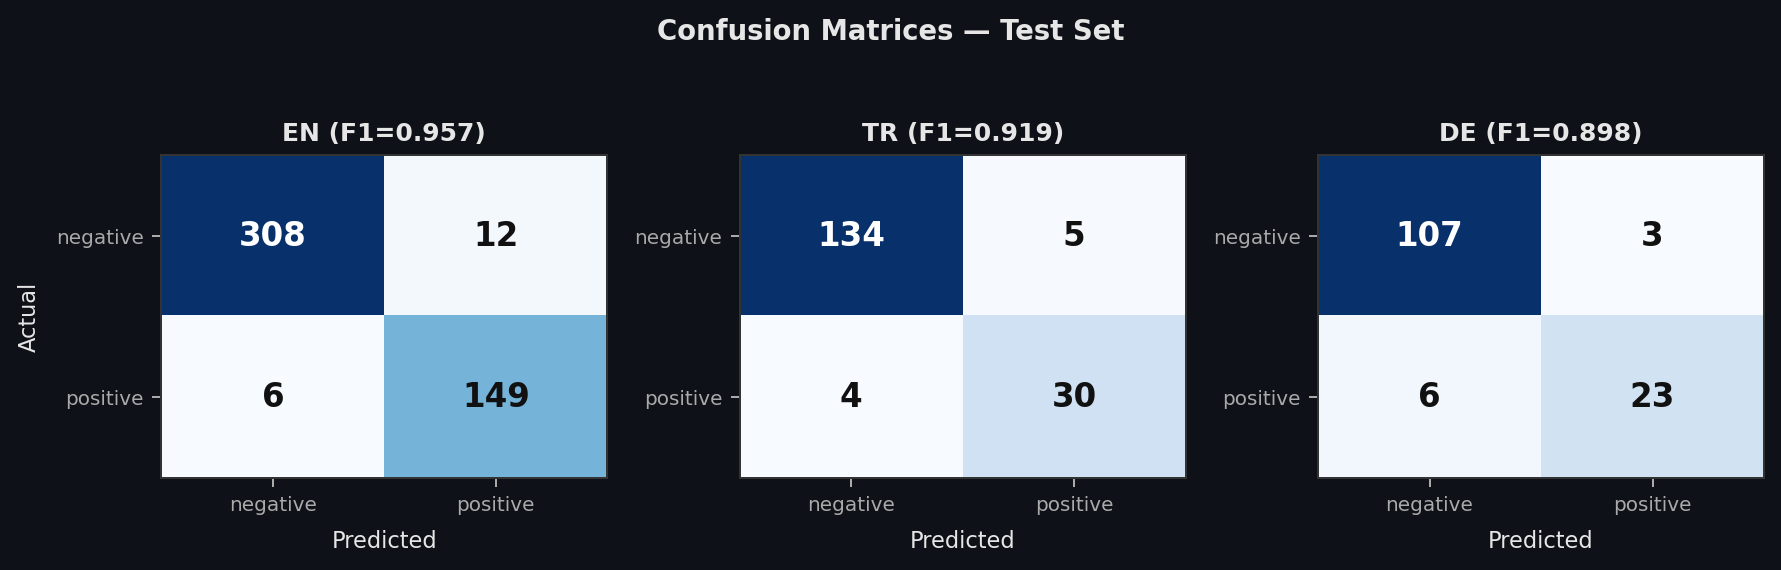

In [16]:
from sklearn.metrics import confusion_matrix

section("7C — Confusion Matrices")

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
label_order = ["negative", "positive"]

for ax, lang in zip(axes, LANGS):
    cm = confusion_matrix(
        test_results[lang]["labels"],
        test_results[lang]["preds"],
        labels=label_order
    )
    im = ax.imshow(cm, cmap="Blues", aspect="auto")

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() * 0.5 else "#111111"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(label_order, fontsize=8)
    ax.set_yticklabels(label_order, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9, labelpad=6)
    if ax is axes[0]:
        ax.set_ylabel("Actual", fontsize=9, labelpad=6)

    ft_f1 = classification_report(
        test_results[lang]["labels"], test_results[lang]["preds"],
        labels=label_order, output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]
    ax.set_title(f"{lang} (F1={ft_f1:.3f})", fontsize=10, fontweight="bold", pad=6)

fig.suptitle("Confusion Matrices — Test Set", fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

### Step 7 Summary

Fine-tuning delivers **+14 to +21 point macro F1 gains** over the zero-shot baseline across all languages. **EN (0.957)** is near-perfect with only 18 misclassifications out of 475. **TR (0.919)** shows the biggest improvement — positive F1 jumped from 0.55 (zero-shot) to 0.870, meaning the model now catches 88% of positive reviews vs 65% before. **DE (0.898)** is the weakest link with positive recall at 0.793 — 6 out of 29 positive reviews misclassified as negative — but this is partly a small test set artifact (29 positive samples). Confusion matrices confirm errors are evenly distributed between false positives and false negatives, with no systematic bias in any language.

## Step 08 — 5-Fold Cross-Validation (TR & DE)

TR and DE test sets are small (173 and 139 samples) — a single lucky or unlucky split could shift F1 by several points. 5-fold stratified CV trains 5 independent models on different data partitions and averages their performance, giving a more reliable estimate of true model capability. EN is skipped here because its test set (475 samples) is large enough for stable evaluation.

In [17]:
section("8A — 5-Fold CV (TR & DE)")

from sklearn.model_selection import StratifiedKFold

for lang in ["TR", "DE"]:
    df_lang = df[df["lang"] == lang].copy()
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(df_lang, df_lang["label"]), 1):
        train_df = df_lang.iloc[train_idx][["review_clean", "label"]].copy()
        val_df   = df_lang.iloc[val_idx][["review_clean", "label"]].copy()
        train_df["labels"] = train_df["label"].map(LABEL2ID)
        val_df["labels"]   = val_df["label"].map(LABEL2ID)

        tokenizer = tokenizers[lang]
        train_ds = (
            Dataset.from_pandas(train_df.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["review_clean", "label"])
        )
        val_ds = (
            Dataset.from_pandas(val_df.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["review_clean", "label"])
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            MODELS[lang], num_labels=2, id2label=ID2LABEL,
            label2id=LABEL2ID, ignore_mismatched_sizes=True,
        )

        labels_arr = train_df["labels"].values
        weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels_arr)
        cw = torch.tensor(weights, dtype=torch.float)

        args = make_training_args(lang)
        args.output_dir = f"/content/drive/MyDrive/SentimentAnalysis/cv_{lang}_fold{fold}"

        trainer = WeightedTrainer(
            model=model, args=args,
            train_dataset=train_ds, eval_dataset=val_ds,
            compute_metrics=make_compute_metrics(),
            class_weights=cw,
        )
        trainer.train()

        preds_output = trainer.predict(val_ds)
        preds = preds_output.predictions.argmax(-1)
        f1 = classification_report(
            preds_output.label_ids, preds,
            labels=[0, 1], output_dict=True, zero_division=0
        )["macro avg"]["f1-score"]
        fold_f1s.append(f1)
        print(f"  {lang} Fold {fold}: F1 = {f1:.3f}")

    print(f"\n  {lang} 5-Fold CV: Mean F1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")


8A — 5-Fold CV (TR & DE)


Map:   0%|          | 0/1104 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: savasy/bert-turkish-text-classification
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  DE Fold 5: F1 = 0.890

  DE 5-Fold CV: Mean F1 = 0.898 ± 0.008


> **Results:** Both languages show **tight variance bands**, confirming the test set results are not artifacts of a lucky split. TR's CV mean (0.915) closely matches its test F1 (0.919), and DE's CV mean (0.898) is **identical** to its test F1. DE's narrower std (±0.008 vs TR's ±0.016) is notable — despite having fewer samples, the model is more consistent, likely because German review language is more formulaic than Turkish. These results give us confidence to deploy without reservations about evaluation reliability.

## Step 09 — Full Dataset Inference & Export

Run the fine-tuned models on all 7,236 reviews to generate ML predictions with confidence scores. This step validates the overall pipeline by measuring **ML vs GPT label agreement** — high agreement confirms successful knowledge distillation from LLM to ML. Low-confidence predictions (< 0.55) are flagged for potential neutral handling in the dashboard layer. Final results are exported to parquet for downstream use.

In [18]:
section("9A — Save Models & Tokenizers")

for lang in LANGS:
    save_path = PATHS["model_" + lang]
    trainers[lang].save_model(str(save_path))
    tokenizers[lang].save_pretrained(str(save_path))
    print(f"  {lang} saved → {save_path}")


9A — Save Models & Tokenizers


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  EN saved → /content/drive/MyDrive/SentimentAnalysis/models_v2/EN


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  TR saved → /content/drive/MyDrive/SentimentAnalysis/models_v2/TR


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  DE saved → /content/drive/MyDrive/SentimentAnalysis/models_v2/DE


In [19]:
section("9B — Full Dataset Inference")

from torch.utils.data import DataLoader

all_preds = []

for lang in LANGS:
    df_lang = df[df["lang"] == lang].copy()
    tokenizer = tokenizers[lang]
    model = trainers[lang].model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
    device = next(model.parameters()).device

    ds = Dataset.from_pandas(df_lang[["review_clean"]].reset_index(drop=True))
    ds = ds.map(lambda b: tokenize(b, tokenizer), batched=True)
    ds.set_format("torch", columns=["input_ids", "attention_mask"])

    loader = DataLoader(ds, batch_size=32)
    preds, confs = [], []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=-1)
            pred_ids = probs.argmax(-1).cpu().tolist()
            max_confs = probs.max(-1).values.cpu().tolist()
            preds.extend(pred_ids)
            confs.extend(max_confs)

    df_lang["ml_sentiment"] = [ID2LABEL[p] for p in preds]
    df_lang["ml_confidence"] = confs
    df_lang["ml_low_confidence"] = df_lang["ml_confidence"] < 0.55
    all_preds.append(df_lang)

    n_low = df_lang["ml_low_confidence"].sum()
    print(f"  {lang}: {len(df_lang)} reviews | low confidence: {n_low} ({n_low/len(df_lang)*100:.1f}%)")

df_results = pd.concat(all_preds, ignore_index=True)
print(f"\n  Total: {len(df_results)} reviews")
print(f"  ML vs GPT label agreement: {(df_results['ml_sentiment'] == df_results['sentiment_binary']).mean()*100:.1f}%")


9B — Full Dataset Inference


Map:   0%|          | 0/4744 [00:00<?, ? examples/s]

  EN: 4744 reviews | low confidence: 1 (0.0%)


Map:   0%|          | 0/1380 [00:00<?, ? examples/s]

  TR: 1380 reviews | low confidence: 7 (0.5%)


Map:   0%|          | 0/1112 [00:00<?, ? examples/s]

  DE: 1112 reviews | low confidence: 0 (0.0%)

  Total: 7236 reviews
  ML vs GPT label agreement: 98.4%


In [20]:
section("9C — Export Results")

df_results.to_parquet(PATHS["results"], index=False)
print(f"  Saved → {PATHS['results']}")
print(f"  Shape: {df_results.shape}")
print(f"  Columns: {list(df_results.columns)}")

# Disagreement örnekleri
disagree = df_results[df_results["ml_sentiment"] != df_results["sentiment_binary"]]
print(f"\n  Disagreements: {len(disagree)} reviews")
print(f"\n  Sample disagreements:")
for _, r in disagree.head(5).iterrows():
    print(f"    [{r['rating']}★ {r['lang']}] GPT={r['sentiment_binary']} ML={r['ml_sentiment']} (conf={r['ml_confidence']:.2f})")
    print(f"      {r['review'][:120]}")


9C — Export Results
  Saved → /content/drive/MyDrive/SentimentAnalysis/outputs_v2/sentiment_results.parquet
  Shape: (7236, 21)
  Columns: ['review_id', 'game', 'country', 'lang', 'rating', 'title', 'review', 'date', 'version', 'days_since_version', 'is_competitor', 'sentiment_binary', 'sentiment_3class', 'char_count', 'has_emoji', 'review_clean', 'label', 'label_id', 'ml_sentiment', 'ml_confidence', 'ml_low_confidence']

  Disagreements: 117 reviews

  Sample disagreements:
    [5★ EN] GPT=positive ML=negative (conf=0.90)
      This was the game before royal kingdom
    [4★ EN] GPT=negative ML=positive (conf=1.00)
      Like the game! Fun and joining a good team helps with lives and bonuses. But I’m annoyed at times by spending real $ and
    [5★ EN] GPT=positive ML=negative (conf=1.00)
      Thanks For Making Me Waste Time
    [5★ EN] GPT=positive ML=negative (conf=0.90)
      Yeah it’s fine. What? You want to make something of it? Come on then
    [5★ EN] GPT=negative ML=positive (

## Summary

This notebook trains language-specific binary sentiment classifiers (negative / positive) for mobile game reviews across English, Turkish, and German. GPT-4.1 pseudo-labels are used as ground truth instead of rating-based heuristics, enabling the models to capture cases where sentiment diverges from star ratings (e.g., 5★ reviews with negative tone). The neutral class was excluded from training due to insufficient samples (209 out of 7,236 — just 17 in German) and is instead handled post-hoc via confidence thresholds in the dashboard layer.

Three transformer models were fine-tuned: `roberta-large` for EN, `savasy/bert-turkish-text-classification` for TR, and `deepset/gbert-base` for DE. All three achieved strong test set performance — macro F1 scores of **0.957 (EN)**, **0.919 (TR)**, and **0.898 (DE)** — representing gains of +14 to +21 points over the zero-shot multilingual baseline. 5-fold cross-validation on TR and DE confirmed the results are stable (TR: 0.915 ± 0.016, DE: 0.898 ± 0.008).

Full dataset inference shows **98.4% agreement between ML predictions and GPT labels**. The 117 disagreements are predominantly sarcastic, mixed-sentiment, or ambiguous edge cases. These models are ready for daily batch inference, delivering GPT-level sentiment quality at a fraction of the cost.